In [1]:
import numpy as np
import xopr
# https://docs.englacial.org/xopr/

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import geoviews as gv
import geoviews.feature as gf
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

import xopr

import holoviews as hv
import hvplot.xarray
import hvplot.pandas
hvplot.extension('bokeh')

In [3]:
# Establish an OPR session
# You'll probably want to set a cache directory if you're running this locally to speed
# up subsequent requests. You can do other things like customize the STAC API endpoint,
# but you shouldn't need to do that for most use cases.
opr = xopr.OPRConnection(cache_dir = "data/xopr_cache")

# Or you can open a connection without a cache directory (for example, if you're parallelizing
# this on a cloud cluster without persistent storage).
#opr = xopr.OPRConnection()

# View available collections

Spatio-Temporal Asset Catalogs (STAC): https://source.coop/englacial/xopr/catalog/hemisphere=south/provider=utig

In [4]:
# List the available OPR datasets
collections = opr.get_collections()
print([c['id'] for c in collections])

['2002_Greenland_P3', '2010_Antarctica_DC8', '2018_Antarctica_BaslerJKB', '1998_Greenland_P3', '2011_Greenland_P3', '2018_Antarctica_DC8', '2016_Antarctica_DC8', '2017_Antarctica_Basler', '2012_Antarctica_DC8', '2009_Antarctica_DC8', '2016_Greenland_TOdtu', '2004_Antarctica_P3chile', '2019_Greenland_P3', '2013_Antarctica_P3', '2005_Greenland_TO', '2013_Greenland_P3', '2009_Antarctica_TO', '1997_Greenland_P3', '1996_Greenland_P3', '1993_Greenland_P3', '2015_Greenland_C130', '2003_Greenland_P3', '2019_Antarctica_GV', '2017_Greenland_P3', '2014_Greenland_P3', '2008_Antarctica_BaslerJKB', '2018_Greenland_P3', '2013_Antarctica_Basler', '2001_Greenland_P3', '1999_Greenland_P3', '2014_Antarctica_DC8', '2017_Antarctica_BaslerJKB', '2010_Greenland_DC8', '2009_Greenland_TO', '2016_Greenland_Polar6', '2016_Greenland_P3', '2011_Antarctica_TO', '2024_Antarctica_GroundGHOST2', '2008_Greenland_TO', '2006_Greenland_TO', '2009_Antarctica_TO_Gambit', '2016_Greenland_G1XB', '2012_Greenland_P3', '1995_Gre

In [5]:
selected_collection = '2016_Antarctica_BaslerJKB'
print(f"Selected collection: {selected_collection}")

Selected collection: 2016_Antarctica_BaslerJKB


In [6]:
# List segments in the selected collection
segments = opr.get_segments(selected_collection)
print(f"Found {len(segments)} segments in collection {selected_collection}")
print(f"The first 3 segments are: {[s['segment_path'] for s in segments[:3]]}")

Found 173 segments in collection 2016_Antarctica_BaslerJKB
The first 3 segments are: ['20170112_01', '20170112_02', '20170112_03']


In [7]:
# Or from the list of segments like this: segments[0]['segment_path']
selected_segment = '20170112_02'
print(f"Selected segment: {selected_segment}")

stac_items = opr.query_frames(collections = [selected_collection], segment_paths = [selected_segment])
stac_items.head(3)

Selected segment: 20170112_02


,collection,geometry,properties,assets,bbox,id,links,stac_extensions,stac_version,type
stac_item_id,,,,,,,,,,
Data_20170112_02_001,2016_Antarctica_BaslerJKB,"LINESTRING (110.48937 -66.27288, 110.66303 -66...",{'datetime': '2017-01-12T05:58:08.905437+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[110.48936944981753, -66.50282644577938, 111.4...",Data_20170112_02_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20170112_02_002,2016_Antarctica_BaslerJKB,"LINESTRING (111.44827 -66.50295, 112.10565 -66...",{'datetime': '2017-01-12T06:09:08.889035+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[111.44826605262807, -66.7262829665125, 112.42...",Data_20170112_02_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20170112_02_003,2016_Antarctica_BaslerJKB,"LINESTRING (112.42577 -66.7264, 112.68354 -66....",{'datetime': '2017-01-12T06:20:48.345425+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[112.42576593327807, -66.94387539038304, 113.4...",Data_20170112_02_003,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature


In [11]:
background_map = gf.ocean.opts(projection = ccrs.SouthPolarStereo(true_scale_latitude = -71), scale = '50m') * gf.coastline.opts(projection = ccrs.SouthPolarStereo(true_scale_latitude = -71), scale = '50m')
# background part might have geoview issues
# background_map * stac_items.to_crs('EPSG:3031').hvplot(aspect = 'equal')

In [10]:
stac_items.to_crs('EPSG:3031').hvplot(aspect = 'equal')

:Path   [x,y]

In [12]:
# do not exist?
frames = opr.load_frames(stac_items)

/opt/miniconda3/envs/ibiz/lib/python3.11/site-packages/xopr/opr_access.py:481: UserWarning: Warning: Unexpected result from ops_api: ERROR: SEGMENT DOES NOT EXIST.
  warnings.warn(f"Warning: Unexpected result from ops_api: {result['data']}", UserWarning)
/opt/miniconda3/envs/ibiz/lib/python3.11/site-packages/xopr/opr_access.py:481: UserWarning: Warning: Unexpected result from ops_api: ERROR: SEGMENT DOES NOT EXIST.
  warnings.warn(f"Warning: Unexpected result from ops_api: {result['data']}", UserWarning)
/opt/miniconda3/envs/ibiz/lib/python3.11/site-packages/xopr/opr_access.py:481: UserWarning: Warning: Unexpected result from ops_api: ERROR: SEGMENT DOES NOT EXIST.
  warnings.warn(f"Warning: Unexpected result from ops_api: {result['data']}", UserWarning)


In [13]:
# Inspect an individual frame
frames[0].xopr

In [14]:
flight_line = xopr.merge_frames(frames)

In [15]:
## Combine the frames into a single xarray Dataset representing the flight line
#flight_line = xr.concat(frames, dim='slow_time', combine_attrs=merge_dicts_no_conflicts).sortby('slow_time')
flight_line.xopr

In [16]:
stacked = flight_line.resample(slow_time = '2s').mean()

stacked['Data'] = 10*np.log10(np.abs(stacked['Data']))

stacked.xopr

In [21]:
layers = opr.get_layers(stacked)
print(layers.keys())
# Does noth contain the bed

dict_keys(['standard:surface'])


In [18]:
layers["standard:surface"] # Display the surface layer as an example

<xarray.Dataset> Size: 420kB
Dimensions:       (slow_time: 10002)
Coordinates:
  * slow_time     (slow_time) datetime64[ns] 80kB 2017-01-12T05:52:30.5881295...
Data variables:
    file_type     <U5 20B 'layer'
    file_version  <U1 4B '1'
    elev          (slow_time) float64 80kB 587.9 587.8 ... 1.931e+03 1.931e+03
    id            float64 8B 1.0
    lat           (slow_time) float64 80kB -66.27 -66.27 ... -66.94 -66.94
    lon           (slow_time) float64 80kB 110.5 110.5 110.5 ... 113.4 113.4
    quality       (slow_time) uint8 10kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    twtt          (slow_time) float64 80kB 4.025e-06 4.025e-06 ... 5.305e-06
    type          (slow_time) uint8 10kB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2 2

In [ ]:
# range and wgs84 views
for layer_idx in layers:
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate = 'wgs84')
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate = 'range')

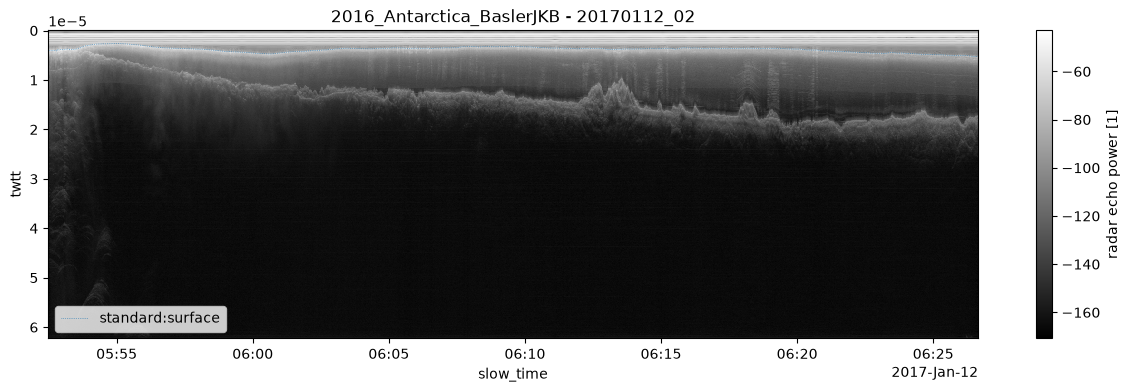

In [ ]:
fig, ax = plt.subplots(figsize = (15, 4))
stacked['Data'].plot.imshow(x = 'slow_time', cmap = 'gray', ax = ax)
ax.invert_yaxis()

if layers:
    for layer_name in layers:
        layers[layer_name]['twtt'].plot(ax = ax, x = 'slow_time', linewidth = 0.5, linestyle = ':', label = layer_name)
ax.legend()

ax.set_title(f"{stacked.attrs['collection']} - {stacked.attrs['segment_path']}")
plt.show() 

In [ ]:
# wgs84 view
vcoord = 'wgs84' # Options are 'range' or 'wgs84'

tmp = xopr.interpolate_to_vertical_grid(stacked, vertical_coordinate=vcoord)

fig, ax = plt.subplots(figsize=(15, 4))
tmp['Data'].plot.imshow(x='slow_time', cmap='gray', ax=ax)
if vcoord == 'range':
    ax.invert_yaxis()

if layers:
    for layer_name in layers:
        layers[layer_name][vcoord].plot(ax = ax, x = 'slow_time', linewidth = 0.5, linestyle = ':', label = layer_name)
    ax.legend()

ax.set_title(f"{stacked.attrs['collection']} - {stacked.attrs['segment_path']}")
plt.show()

In [ ]:
# Citation does not work here
print(flight_line.xopr.citation)